# MiniLM Benchmark - Symptoms Disease Classification

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"

c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds = ds["validation"].rename_column("text_cleaned", "text")
test_ds = ds["test"].rename_column("text_cleaned", "text")

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 23541
})

In [3]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

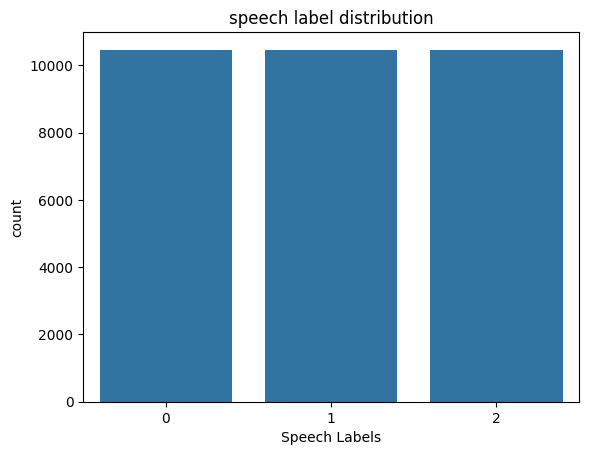

In [5]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.show()

In [6]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 3


## Load MiniLM Model

In [7]:
mini_lm = "microsoft/MiniLM-L12-H384-uncased"

mini_lm_tokenizer = AutoTokenizer.from_pretrained(mini_lm)

mini_lm_model = AutoModelForSequenceClassification.from_pretrained(
    mini_lm,
    num_labels=total_labels,
)

mini_lm_model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1322.69it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12,

In [8]:
# Total number of parameters
mini_lm_params = sum(p.numel() for p in mini_lm_model.parameters() if p.requires_grad)
print(f"MiniLM parameters: {mini_lm_params:,}")

MiniLM parameters: 33,361,155


## Tokenizing Dataset

In [9]:
def tokenize(batch):
    return mini_lm_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_val = val_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_test = test_ds.map(tokenize, batched=True, batch_size=1024)

Map: 100%|██████████| 1962/1962 [00:00<00:00, 14833.39 examples/s]


In [10]:
tokenized_train, tokenized_val, tokenized_test

(Dataset({
     features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 23541
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 5886
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 1962
 }))

In [11]:
# remove the raw text column, we dont want a string
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [12]:
tokenized_train

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 23541
})

## Model Training (Fine Tuning)

In [13]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

In [14]:
LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCH = 3

output_path = "./results/mini_lm"

training_args = TrainingArguments(
    output_dir=output_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [15]:
data_collator = DataCollatorWithPadding(mini_lm_tokenizer)

In [16]:
trainer = Trainer(
    model=mini_lm_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.592070,0.545558,0.761978,0.752163
2,0.489317,0.500118,0.776589,0.768128
3,0.425396,0.489905,0.783554,0.775890


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.30it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=4416, training_loss=0.5137850650842639, metrics={'train_runtime': 415.5471, 'train_samples_per_second': 169.952, 'train_steps_per_second': 10.627, 'total_flos': 2326106672967168.0, 'train_loss': 0.5137850650842639, 'epoch': 3.0})

In [18]:
trainer.save_model(output_path)
mini_lm_tokenizer.save_pretrained(output_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.88it/s]


('./results/mini_lm\\tokenizer_config.json',
 './results/mini_lm\\tokenizer.json')

## Model Evaluation

In [19]:
eval_results = trainer.evaluate(eval_dataset=tokenized_test)
eval_results

{'eval_loss': 0.4755410850048065,
 'eval_accuracy': 0.7915392456676861,
 'eval_f1': 0.7849563358802727,
 'eval_runtime': 3.5567,
 'eval_samples_per_second': 551.641,
 'eval_steps_per_second': 34.583,
 'epoch': 3.0}

In [20]:
pred = trainer.predict(test_dataset=tokenized_test)
pred.predictions, pred.label_ids

(array([[-0.7586377 , -1.5590456 ,  2.7885828 ],
        [ 2.511547  , -1.5325978 , -1.0323548 ],
        [ 0.818939  ,  2.0423346 , -3.5588167 ],
        ...,
        [ 0.95479107,  1.9614819 , -3.6203685 ],
        [-1.0595046 , -1.942472  ,  3.7146473 ],
        [ 0.9757142 ,  1.9111478 , -3.581701  ]],
       shape=(1962, 3), dtype=float32),
 array([2, 0, 0, ..., 1, 2, 1], shape=(1962,)))

In [21]:
pred_labels = np.argmax(pred.predictions, axis=1)
pred_labels

array([2, 0, 1, ..., 1, 2, 1], shape=(1962,))

In [22]:
y_df = pd.DataFrame({
    "predicted": pred_labels,
    "true": pred.label_ids,
})
y_df.head()

,predicted,true
0,2,2
1,0,0
2,1,0
3,1,0
4,1,1


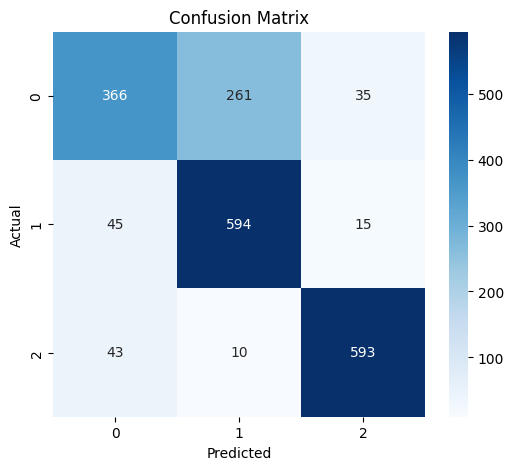

In [23]:
cm = confusion_matrix(pred.label_ids, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
report = classification_report(pred.label_ids, pred_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
0,0.806167,0.552870,0.655914,662.000000
1,0.686705,0.908257,0.782093,654.000000
2,0.922240,0.917957,0.920093,646.000000
accuracy,0.791539,0.791539,0.791539,0.791539
macro avg,0.805037,0.793028,0.786034,1962.000000
weighted avg,0.804564,0.791539,0.784956,1962.000000


# Inference Example

In [26]:
output_path = "./results/mini_lm"

tokenizer = AutoTokenizer.from_pretrained(output_path)
model = AutoModelForSequenceClassification.from_pretrained(output_path)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1028.81it/s, Materializing param=classifier.weight]                                     


In [28]:
model.config.id2label = {0: "hate", 1: "offensive", 2: "neither"}
model.config.label2id = {v:k for k,v in model.config.id2label.items()}

In [29]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

classifier("you are so stupid")

[{'label': 'hate', 'score': 0.9617058038711548}]